In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")
schema = pd.read_sql("PRAGMA table_info(checker);", conn)

print(schema)

   cid       name       type  notnull dflt_value  pk
0    0      index    INTEGER        0       None   0
1    1     status       TEXT        0       None   0
2    2    success    INTEGER        0       None   0
3    3  timestamp  TIMESTAMP        0       None   0
4    4  numTrials    INTEGER        0       None   0
5    5    labname       TEXT        0       None   0
6    6        uid       TEXT        0       None   0


In [3]:
df = pd.read_sql(
    '''
    SELECT timestamp AS commits
    FROM checker
    WHERE uid LIKE 'user_%'
    ''',
    conn,
    parse_dates=['commits'],
)

df['daytime'] = pd.cut(
    df['commits'].dt.hour, 
    bins=[0, 4, 10, 17, 24], 
    labels=['night','morning', 'afternoon', 'evening']
)

pivot_table = df.pivot_table(
    index=df['commits'].dt.date,
    columns='daytime',
    aggfunc='count',
    values='commits',
    observed=False
)

In [4]:
print(pivot_table.shape)
pivot_table.head()

(35, 4)


daytime,night,morning,afternoon,evening
commits,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,40,28
2020-04-19,0,11,9,11
2020-04-20,0,0,15,10
2020-04-21,0,0,9,16


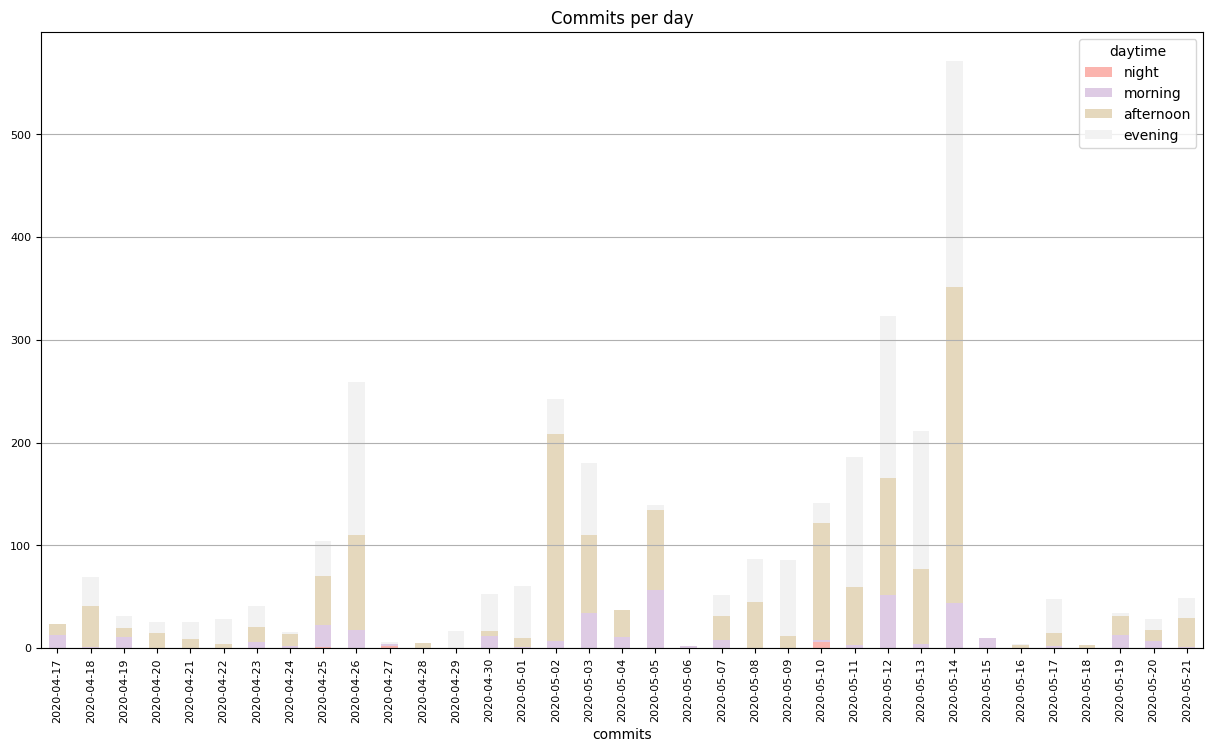

In [5]:
pivot_table.plot(
    kind='bar',
    stacked=True,
    fontsize=8,
    figsize=(15, 8),
    title='Commits per day',
    rot=90,
    cmap='Pastel1',
).grid(axis='y')

- When do our users usually commit the labs: in the night, morning, afternoon, or evening? Afternoon, evening.  
- Which day has: the most number of commits and at the same time, the number of commits in the evening is higher than in the afternoon? 2020-05-12.

In [6]:
conn.close()